<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Intermediate_NLP_Word_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
google_wiki_words_tensorflow2_250_1_path = kagglehub.model_download('google/wiki-words/TensorFlow2/250/1')

print('Data source import complete.')



  0%|          | 0.00/963M [00:00<?, ?B/s]



  0%|          | 0.00/23.0k [00:00<?, ?B/s]

100%|██████████| 23.0k/23.0k [00:00<00:00, 13.3MB/s]





100%|██████████| 218/218 [00:00<00:00, 995kB/s]


  0%|          | 0.00/8.27M [00:00<?, ?B/s]
  0%|          | 1.00M/963M [00:00<06:35, 2.55MB/s]
  0%|          | 3.00M/963M [00:00<02:22, 7.05MB/s]

 12%|█▏        | 1.00M/8.27M [00:00<00:02, 2.67MB/s]
  1%|          | 8.00M/963M [00:00<00:53, 18.8MB/s]

 36%|███▋      | 3.00M/8.27M [00:00<00:00, 7.36MB/s]
  1%|▏         | 13.0M/963M [00:00<00:35, 27.9MB/s]

100%|██████████| 8.27M/8.27M [00:00<00:00, 20.1MB/s]
100%|██████████| 8.27M/8.27M [00:00<00:00, 14.1MB/s]

  3%|▎         | 25.0M/963M [00:00<00:22, 42.9MB/s]
  3%|▎         | 31.0M/963M [00:01<00:20, 46.6MB/s]
  4%|▍         | 37.0M/963M [00:01<00:19, 50.0MB/s]
  4%|▍         | 43.0M/963M [00:01<00:18, 51.5MB/s]
  5%|▌         | 49.0M/963M [00:01<00:17, 53.4MB/s]
  6%|▌         | 55.0M/963M [00:01<00:17, 54.3MB/s]
  6%|▋         | 61.0M/963M [00:01<00:17, 54.6MB/s]
  7%|▋         | 67.0M/963M [00:01<00:17, 55.0MB/s]
  8%|▊         | 73.0M/963M [00:01<00:16, 55.5MB/s]
  8%|▊    

Data source import complete.


# Intermediate NLP: Word Embeddings

Welcome to the first module of this course where we will explore one of the most powerful and life-changing concepts in Natural Language Processing (NLP): **Word Embeddings**.

By the end of this session, you will understand how modern algorithms convert words into rich, meaningful mathematical vectors, and how to use these vectors to look at the meaning-based relationships between words. Let's dive in!


## Introduction

Before the arrival of embeddings, traditional NLP relied on frequency-based ways to show words. If we have a vocabulary of 10,000 unique words, these methods represent every single sentence as a 10,000-dimensional vector.

The simplest approach is Bag-of-Words (BoW) as it simply counts the number of times a word appears in a document. It completely ignores word order and grammar. A smarter version of BoW is TF-IDF (Term Frequency-Inverse Document Frequency). It scales the word counts based on how rare a word is across the entire dataset. This helps highlight important, document-specific words (like "embedding") while down-weighting common filler words (like "the" or "is").

While useful for basic tasks, both BoW and TF-IDF suffer from two major problems:

1. Massive and Empty (Mostly zeros): A 10,000-word vocabulary means a 10,000-dimensional vector, mostly filled with zeros. This takes up a huge amount of memory.
2. Mathematically Independent (No Meaning): In these models, each word is its own independent dimension. Mathematically, the distance between "dog" and "puppy" is exactly the same as the distance between "dog" and "spaceship". The model has zero understanding of meaning-based similarities.

Word embeddings solve this by shrinking these massive, mostly zeros vectors into dense, lower-dimensional versions where geometric closeness means the same as meaning-based meaning! Let's compare word embeddings with other methods like Bag-of-Words/TF-IDF in the table below.

| Feature | Traditional NLP (Bag-of-Words/TF-IDF) | Word Embeddings (Word2Vec/GloVe) |
|---|---|---|
| **Ways to show** | Large, empty vectors (e.g., size 10,000+) | Dense, low-dimensional vectors (e.g., size 50 to 300) |
| **Meaning/Context** | Ignored. Words are mathematically unrelated (independent). | Captured. Words with similar meanings have mathematically similar vectors. |
| **Data Efficiency** | Memory-intensive due to thousands of zeros. | Highly efficient and shrunk. |
| **Usage** | Counts the simple occurrence of words. | Represents deep meaning-based relationships. |

To help understand why embeddings are so powerful, let's start with a simple example. Imagine a 4-dimensional mathematical space where each dimension represents an abstract concept. Let's define our 4 dimensions as `[Feline, Canine, Age, Domesticity]`. We can score concepts on a scale (e.g., 0.0 to 1.0):

* **Feline:** (0 = Not Feline, 1 = Feline)
* **Canine:** (0 = Not Canine, 1 = Canine)
* **Age:** (0 = Youth, 1 = Adult)
* **Domesticity:** (0 = Wild, 1 = Pet)

If we plot words as 4D mathematical vectors on this graph:

* "Dog" might sit at `[0.0, 1.0, 1.0, 1.0]`
* "Puppy" might sit at `[0.0, 1.0, 0.0, 1.0]`
* "Cat" might sit at `[1.0, 0.0, 1.0, 1.0]`
* "Kitten" might sit at `[1.0, 0.0, 0.0, 1.0]`
* "Wolf" might sit at `[0.0, 1.0, 1.0, 0.0]`

In word embeddings, the spatial distance between two vectors tells us how related they are. Because "Dog" and "Cat" share identical values in Age and Domesticity, their vectors point in a similar direction in this 4D space. "Wolf," sharing very few traits with "Kitten", is mathematically far away.

How does the computer actually calculate this "closeness"? It uses a mathematical formula called **Cosine Similarity**, which measures the angle between two vectors A and B.

The formula for Cosine Similarity is:
$$ \text{Cosine Similarity} = \frac{A \cdot B}{||A|| \times ||B||} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $$

* If the words mean the exact same thing, the angle between their vectors is 0 degrees, and the Cosine Similarity is **1**.
* If the words are completely unrelated, their vectors are perpendicular (90 degrees), and the Cosine Similarity is **0**.

In reality, embeddings use 100 or 300 dimensions instead of just 4. These dimensions don't always have a direct human analogue; instead, they capture the subtle semantic gradients and latent nuances—the unnamed "vibes"—that often slip through the cracks of literal definitions, including grammar, emotion, context, and syntax

## Loading Pre-Trained Word Embeddings: Wiki-words

Training an embedding model from scratch requires a massive amount of text and heavy computational power. Fortunately, we can utilize **pre-trained** models!

For this section, we will use the [Wiki-words](https://www.kaggle.com/models/google/wiki-words/) model provided by Google via TensorFlow Hub.

Wiki-words is a token-based text embedding trained on the English Wikipedia corpus. The specific version we are loading maps each word token to a 250-dimensional mathematical vector (as indicated by the `/250/` in the model URL and our padding configuration).

This model will be helpful for our modeling task in this course. Here are the main reasons:

1. **Meaning-based Richness**: Because it is trained on all of English Wikipedia, it already understands rich meaning-based relationships, grammar, and context out-of-the-box.
2. **RNN Compatibility**: Recurrent Neural Networks (RNNs) require input sequences of a fixed length and dimension. This model seamlessly converts our split string tokens into uniform 250-dimensional arrays.

First, we need to import our required libraries and load the pre-trained embedding model. We are using `tensorflow_hub` to download the Wiki-words model directly from Google. It will take a word and convert it into a dense, 250-dimensional mathematical vector.

In [2]:
import kagglehub
import tensorflow_hub as hub
import numpy as np

# Download the model using kagglehub for better performance on Kaggle
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
# Load the 250-dimensional Wiki-words embedding model from tensorFlow hub
embed = hub.load(model_path)

## Meaning-Based Similarity: Visualizing and Measuring Meaning

The true magic of word embeddings is that they map meaning-based meaning into geometric space. Words and sentences with similar meanings end up close to each other, while unrelated concepts are pushed far apart.

We can check this "closeness" in two ways: **visually** (by graphing the vectors) and **mathematically** (by calculating the exact distance between them).

To see if our embeddings truly capture sentiment, we can shrink our high-dimensional 250D arrays into just 2 dimensions using **Principal Component Analysis (PCA)**.

Let's encode a few very simple, custom sentiment sentences. We will calculate a single "sentence vector" for each by averaging its words, and then plot them on an X/Y graph to see where they land!

In [3]:
import numpy as np

# 1. Define simple positive and negative sentences
simple_sentences = [
    "excellent",
    "great",
    "terrible",
    "awful"
]
# 1 for positive, 0 for negative
simple_labels = [1, 1, 0, 0]

# 2. Get embeddings using our previously defined function
def get_word2vec_enc(texts):
    """
    Get the 250-dimensional vector value for each word in the sentence.
    """
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

simple_encoded = get_word2vec_enc(simple_sentences)

# 3. Calculate a single "sentence vector" for each by taking the mean of its words
sentence_embeddings = np.array([np.mean(enc, axis=0) for enc in simple_encoded])
print(f"Shape of our simple sentence embeddings: {sentence_embeddings.shape}")

Shape of our simple sentence embeddings: (4, 250)


Now that we have a single 250-dimensional vector for each simple sentence, we will use PCA (Principal Component Analysis) to shrink these 250 dimensions down to just 2 dimensions (X and Y coordinates).

In [4]:
from sklearn.decomposition import PCA

# Reduce the 250-dimensional vectors down to 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(sentence_embeddings)

print(f"Shape after PCA reduction: {embeddings_2d.shape}")

Shape after PCA reduction: (4, 2)


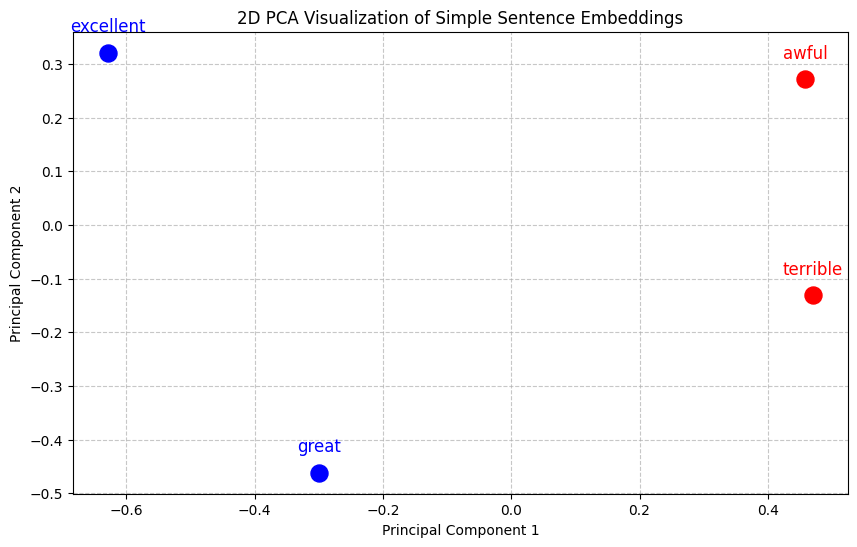

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot each simple sentence
for i, label in enumerate(simple_labels):
    color = 'blue' if label == 1 else 'red'
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], color=color, s=150)
    plt.annotate(simple_sentences[i], (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 textcoords="offset points", xytext=(0,15), ha='center', color=color, fontsize=12)

plt.title("2D PCA Visualization of Simple Sentence Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**What does this image tell us?**
As you can see, the positive sentences cluster together in one area of the graph, while the negative sentences cluster in a completely different area. The embeddings have successfully grouped the text by sentiment!

## Measuring Similarity Mathematically

While visualizations are great for human intuition, computers rely on exact numbers. Because our words are mathematical vectors, we can calculate precisely how closely related two words are.

We calculate this using **Cosine Similarity**, which measures the angle between two vectors A and B. If words are similar in meaning, the angle between them is small, and their similarity score will be closer to **1**. If words are unrelated, their score will be much lower.

Let's test this mathematical formula using simple sentiment vocabulary. We will compare the positive word **"excellent"** to a similarly positive word (**"great"**) and an opposing negative word (**"terrible"**). We expect "excellent" to be mathematically closer to "great" than it is to "terrible".

In [6]:
import numpy as np

def calc_cosine_similarity(A, B):
    """Calculates the cosine similarity between two vectors."""
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

# 1. Get embeddings for our simple words
# Calling .numpy() converts the TensorFlow tensor back to a standard NumPy array
excellent_vector = embed(["excellent"])[0].numpy()
great_vector = embed(["great"])[0].numpy()
terrible_vector = embed(["terrible"])[0].numpy()

# 2. Calculate the Cosine Similarities
sim_excellent_great = calc_cosine_similarity(excellent_vector, great_vector)
sim_excellent_terrible = calc_cosine_similarity(excellent_vector, terrible_vector)

print(f"Similarity between 'excellent' and 'great': {sim_excellent_great:.4f}")
print(f"Similarity between 'excellent' and 'terrible': {sim_excellent_terrible:.4f}")

Similarity between 'excellent' and 'great': 0.6199
Similarity between 'excellent' and 'terrible': 0.2855


Just as we expected, the similarity between "excellent" and "great" (0.6199) is significantly higher than the similarity between "excellent" and "terrible" (0.2855).

By representing text as dense mathematical vectors, our model natively understands the real-world meaning-based relationships between words, enabling it to process language with incredible nuance!

Just as we expected, the similarity between "excellent" and "great" (0.6199) is significantly higher than the similarity between "excellent" and "terrible" (0.2855).

By representing text as dense mathematical vectors, our model natively understands the real-world meaning-based relationships between words, enabling it to process language with incredible nuance!

## Conclusion & Next Steps
In this module, we left behind rigid, frequency-based methods like Bag-of-Words and TF-IDF. Instead, we learned how to represent text as dense mathematical vectors using pre-trained embeddings (Wiki-words). This approach allows our models to natively understand meaning by grouping related words geometrically in space.

While static embeddings like Word2Vec and GloVe are extremely powerful, they assign a single, fixed vector to every word. This means they cannot distinguish context—for example, the word "bank" has the same mathematical representation in "river bank" as it does in "bank account." Modern NLP systems solve this by using contextual embeddings (like BERT) that calculate the meaning of a word dynamically based on its surrounding sentence.

Now that we have rich, meaning-based representations of individual words, we need to prepare entire sentences for deep learning. In **[Module 2: Preparing Text Data](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-preparing-text-data)**, we will build a data engineering pipeline to handle varying sentence lengths and format our embeddings into uniform numerical matrices.